# 1. Problem Definition
 The aim of the model that is to be built is to predict the customer churn (the rate at which customers leave) of a telecommunication company

# 2. Data
 The dataset for the model was obtained from Telco Customer Churn on kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

# 3. Evaluation
 The model must have an acc

# 4. Features
 -

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

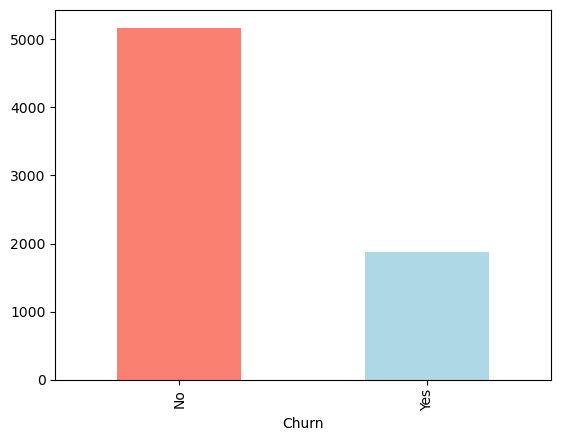

In [7]:
df["Churn"].value_counts().plot( kind = "bar", color = ("salmon", "lightblue"));

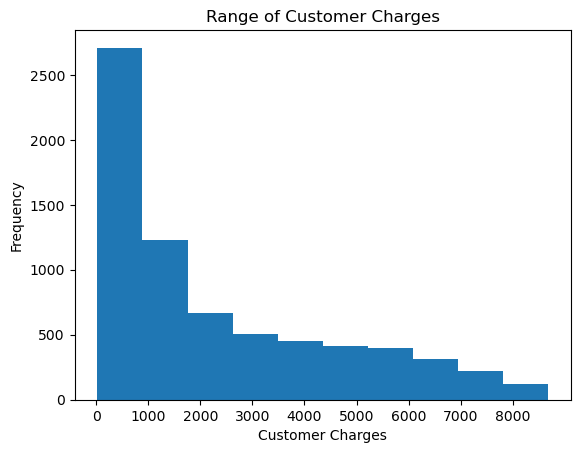

In [8]:
pd.to_numeric(df.TotalCharges, errors= "coerce").plot.hist()
plt.title("Range of Customer Charges")
plt.xlabel("Customer Charges")
plt.xticks(np.arange(0,9000,1000));

In [9]:
pd.crosstab(df.SeniorCitizen, df.Churn)

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


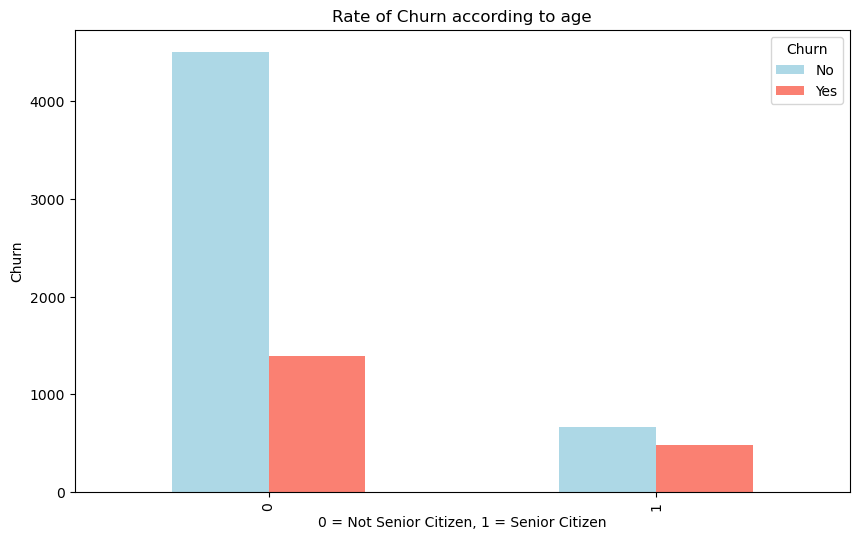

In [10]:
pd.crosstab(df.SeniorCitizen, df.Churn).plot(kind = "bar",
                                             figsize = (10, 6),
                                             color = ("lightblue", "salmon"))
plt.title("Rate of Churn according to age")
plt.xlabel("0 = Not Senior Citizen, 1 = Senior Citizen")
plt.ylabel("Churn");

In [11]:
# Correlation Matrix
df.corr(numeric_only = True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [12]:
# Making a copy of the dataset
df_temp = df.copy()

In [13]:
# Converting Categorical to Boolean datatype
boolean_columns = ['Partner','Dependents','PhoneService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'Churn']

df_temp[boolean_columns] = df_temp[boolean_columns].replace({"Yes": True, "No": False, "No internet service": False})

# Converting Boolean datatypes to numeric datatypes
df_temp[boolean_columns] = df_temp[boolean_columns].astype(int)

df_temp = df_temp.infer_objects(copy=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_18156\2327616528.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp[boolean_columns] = df_temp[boolean_columns].replace({"Yes": True, "No": False, "No internet service": False})


In [14]:
df_temp = pd.get_dummies(df_temp,
                   columns= ['gender','MultipleLines', 'InternetService', 'Contract', 'PaymentMethod'],
                   drop_first= True)

In [15]:
# Coverting TotalCharges to numeric datatype
df_temp["TotalCharges"] = pd.to_numeric(df_temp["TotalCharges"], errors = "coerce")

# Filling in missing data
df_temp["TotalCharges"] = df_temp['TotalCharges'].fillna(df_temp['TotalCharges'].median())

In [16]:
df_temp.drop("customerID", axis = 1, inplace= True)

In [17]:
df_temp.dtypes

SeniorCitizen                              int64
Partner                                    int32
Dependents                                 int32
tenure                                     int64
PhoneService                               int32
OnlineSecurity                             int32
OnlineBackup                               int32
DeviceProtection                           int32
TechSupport                                int32
StreamingTV                                int32
StreamingMovies                            int32
PaperlessBilling                           int32
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int32
gender_Male                                 bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year   

In [18]:
df_temp.isna().sum()

SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMeth

In [19]:
# Converting categorical data to numeric
X = df_temp.drop(columns=["Churn"], axis = 1)
y = df_temp.Churn

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2)

In [20]:
y_train.shape

(5634,)

## Modelling

In [21]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state= 42)

clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
clf.score(X_test, y_test)

0.7991483321504613

In [23]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state = 42, solver= "liblinear" ,max_iter= 200)

clf.fit(X_train, y_train)

LogisticRegression(max_iter=200, random_state=42, solver='liblinear')

In [24]:
clf.score(X_test, y_test)

0.8126330731014905

In [25]:
# XGBoost
clf = xgb.XGBClassifier(random_state = 42)

clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [26]:
clf.score(X_test, y_test)

0.8034066713981547

## Hyperparameter Tuning

In [27]:
# Using RandomizedSearchCV on Random Forest Classifier
rf_grid ={"n_estimators" : np.arange(100,1500,100),
          "max_depth" : [None, 3, 5, 10, 20, 30],
          "min_samples_split": np.arange(2,10,2),
          "min_samples_leaf": np.arange(1,10,2),
          "max_features" : [0.5, 1,'log2','sqrt'],}

lg_grid = {"C": np.logspace(-4,4,21),
           "solver": ["liblinear"],
           "max_iter" : np.arange(200, 2000, 200)}

xg_grid = {"n_estimators": np.arange(10,100,10),
           "max_depth": [None, 3, 5, 10],
           "learning_rate": np.arange(0.1,1,0.1),
           "subsample": np.arange(0.1,1,0.1),
           "reg_alpha": np.arange(0.1,1,0.1),
           "reg_lambda": np.arange(0.1,1,0.1),}

In [28]:
%%time
# Random Forest Classifier
rf_clf = RandomizedSearchCV(RandomForestClassifier(random_state =42),
                            param_distributions = rf_grid,
                            n_iter = 100,
                            cv = 5,
                            verbose = True)

rf_clf.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 42min 30s
Wall time: 48min 39s


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'max_depth': [None, 3, 5, 10, 20, 30],
                                        'max_features': [0.5, 1, 'log2',
                                                         'sqrt'],
                                        'min_samples_leaf': array([1, 3, 5, 7, 9]),
                                        'min_samples_split': array([2, 4, 6, 8]),
                                        'n_estimators': array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100,
       1200, 1300, 1400])},
                   verbose=True)

In [29]:
rf_clf.score(X_test, y_test)

0.8126330731014905

In [30]:
%%time
# Logistic Regression
lg_clf = RandomizedSearchCV(LogisticRegression(random_state =42),
                            param_distributions = lg_grid,
                            n_iter = 100,
                            cv = 5,
                            verbose = True)

lg_clf.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 43.4 s
Wall time: 24.3 s


RandomizedSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
                   n_iter=100,
                   param_distributions={'C': array([1.00000000e-04, 2.51188643e-04, 6.30957344e-04, 1.58489319e-03,
       3.98107171e-03, 1.00000000e-02, 2.51188643e-02, 6.30957344e-02,
       1.58489319e-01, 3.98107171e-01, 1.00000000e+00, 2.51188643e+00,
       6.30957344e+00, 1.58489319e+01, 3.98107171e+01, 1.00000000e+02,
       2.51188643e+02, 6.30957344e+02, 1.58489319e+03, 3.98107171e+03,
       1.00000000e+04]),
                                        'max_iter': array([ 200,  400,  600,  800, 1000, 1200, 1400, 1600, 1800]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [31]:
lg_clf.score(X_test, y_test)

0.8126330731014905

In [32]:
%%time
# Random Forest Classifier
xg_clf = RandomizedSearchCV(xgb.XGBClassifier(random_state =42),
                            param_distributions = xg_grid,
                            n_iter = 100,
                            cv = 5,
                            verbose = True)

xg_clf.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 4min 4s
Wall time: 1min 41s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   n_iter=100,
                   param_distributions={'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                                        'max_depth': [None, 3, 5, 10],
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90]),
                                        'reg_alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                                        'reg_lambda': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                                        'subsample': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
                   verbose=True)

In [33]:
xg_clf.score(X_test, y_test)

0.8048261178140526

## Trying GridSearchCV

In [35]:
%%time

# Random Forest Classifier
grf_grid = {"n_estimators" : np.arange(10,100,10),
            "max_depth" : [10],
            "min_samples_split": [6,7,8],
            "min_samples_leaf": [1,2,3],
            "max_features" : ['log2'],}

grf_clf = GridSearchCV(RandomForestClassifier(random_state = 42),
                      param_grid= grf_grid,
                      cv = 5,
                      verbose = True)

grf_clf.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
CPU times: total: 1min 57s
Wall time: 2min 3s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [10], 'max_features': ['log2'],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [6, 7, 8],
                         'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
             verbose=True)

In [36]:
grf_clf.score(X_test,y_test)

0.8133427963094393

In [37]:
lg_clf.best_params_

{'solver': 'liblinear', 'max_iter': 600, 'C': 0.15848931924611143}

In [60]:
xg_clf.best_params_

{'subsample': 0.6,
 'reg_lambda': 0.2,
 'reg_alpha': 0.30000000000000004,
 'n_estimators': 40,
 'max_depth': 3,
 'learning_rate': 0.1}

In [55]:
%%time

glg_grid = {"C": np.arange(0.11,0.2,0.01),
           "solver" : "liblinear",
           "max_iter": np.arange(500,700,10)}

glg_clf = GridSearchCV(LogisticRegression(random_state = 42),
                       param_grid = glg_grid,
                       cv= 5,
                       verbose = True)

glg_clf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 5.75 s
Wall time: 3.12 s


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': [0.15848931924611143],
                         'max_iter': array([500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620,
       630, 640, 650, 660, 670, 680, 690]),
                         'solver': ['liblinear']},
             verbose=True)

In [56]:
glg_clf.score(X_test, y_test)

0.8126330731014905

In [ ]:
glg_grid = {"C": np.arange(0.11,0.2,0.01),
           "solver" : "liblinear",
           "max_iter": np.arange(500,700,10)}

glg_clf = GridSearchCV(LogisticRegression(random_state = 42),
                       param_grid = glg_grid,
                       cv= 5,
                       verbose = True)

glg_clf.fit(X_train, y_train)